# Breast Cancer Prediction Analysis

This notebook explores a breast cancer prediction dataset from Kaggle.

The goal is to investigate patterns, relationships and possible indicators connected to breast cancer diagnosis using pandas, matplotlib and seaborn.

Dataset source:
https://www.kaggle.com/datasets/merishnasuwal/breast-cancer-prediction-dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/Breast_cancer_data.csv")

df.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


## Initial Inspection

Before creating visualizations, it is important to understand the structure of the dataset.

The following cells inspect:

* number of rows and columns
* column names
* data types
* missing values
* summary statistics

In [3]:
df.shape

(569, 6)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mean_radius      569 non-null    float64
 1   mean_texture     569 non-null    float64
 2   mean_perimeter   569 non-null    float64
 3   mean_area        569 non-null    float64
 4   mean_smoothness  569 non-null    float64
 5   diagnosis        569 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 26.8 KB


In [5]:
df.describe()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,1.000000


In [6]:
df.isnull().sum()

mean_radius        0
mean_texture       0
mean_perimeter     0
mean_area          0
mean_smoothness    0
diagnosis          0
dtype: int64

In [7]:
print(df['diagnosis'].value_counts())

diagnosis
1    357
0    212
Name: count, dtype: int64


In [8]:
df.groupby('diagnosis')[['mean_radius', 'mean_area']].mean()

,mean_radius,mean_area
diagnosis,,
0,17.462830,978.376415
1,12.146524,462.790196


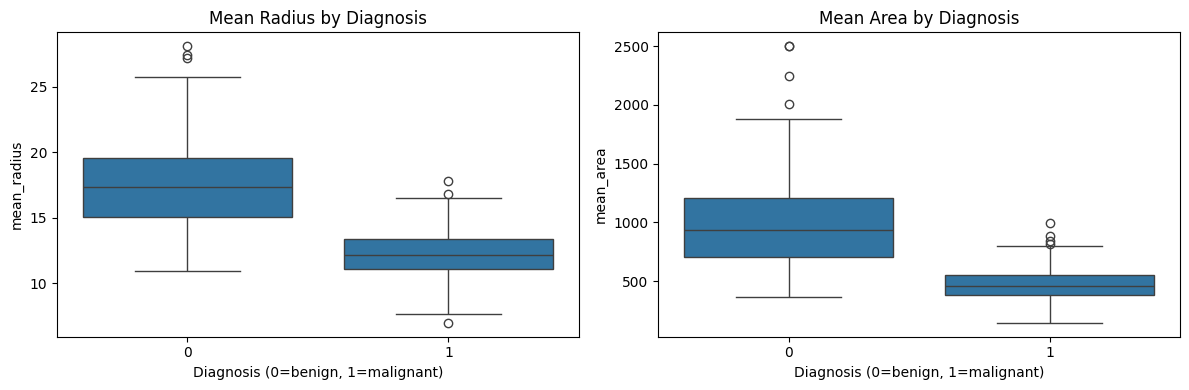

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x='diagnosis', y='mean_radius', data=df, ax=axes[0])
axes[0].set_title('Mean Radius by Diagnosis')
axes[0].set_xlabel('Diagnosis (0=benign, 1=malignant)')

sns.boxplot(x='diagnosis', y='mean_area', data=df, ax=axes[1])
axes[1].set_title('Mean Area by Diagnosis')
axes[1].set_xlabel('Diagnosis (0=benign, 1=malignant)')

plt.tight_layout()
plt.show()

The boxplots show that both mean radius and mean area are generally higher for benign tumors (0) than malignant tumors (1) in this dataset.
This means these features separate the two groups, so they are useful for analysis and later prediction modeling.